In [1]:
import pandas as pd
import os

In [2]:
seed = 20

DIR_RAW = './dataset_raw'
DIR_SPLIT_OUT = './dataset_split'

dataset_name_dir = 'house_price_traj'
col_traj_id = 'traj_id'

In [3]:
df_features = pd.read_csv(os.path.join(DIR_RAW, dataset_name_dir,'df_features.csv'), index_col=0)
df_features = df_features.set_index(col_traj_id)
cols_feats = df_features.columns
n_unique_val_per_col = df_features.nunique()
col_numer = n_unique_val_per_col.index[n_unique_val_per_col > 5]
col_cat = [i for i in df_features.columns if i not in col_numer and i != col_traj_id]
df_features = df_features.reset_index()

df_event_time = pd.read_csv(os.path.join(DIR_RAW, dataset_name_dir,'df_state_history_sampled_max.csv'),  index_col=0)


In [4]:
df_features.head()

,traj_id,feat__is_new_build,feat__long,feat__lat,feat__frac_properties_n_beds__1,feat__frac_properties_n_beds__2,feat__frac_properties_n_beds__3,feat__frac_properties_n_beds__4,feat__frac_properties_n_beds__>=5,feat__tenure__owned_outright,...,feat__deprived_2_dim,feat__deprived_3_dim,feat__deprived_4_dim,feat__soc_grade_AB,feat__soc_grade_C1,feat__soc_grade_C2,feat__soc_grade_DE,feat__prop_type_Detached,feat__prop_type_SemiD,feat__prop_type_Terraced
0,E07000223DetachedExisting,False,-0.32433,50.84573,0.005065,0.056837,0.370287,0.372538,0.195273,0.578788,...,0.203324,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,True,False,False
1,E07000223FlatExisting,False,-0.32433,50.84573,0.075017,0.712319,0.186511,0.019959,0.006194,0.226782,...,0.203324,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,False,False,False
2,E07000223SemiExisting,False,-0.32433,50.84573,0.006395,0.114341,0.628295,0.201938,0.049031,0.416104,...,0.203324,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,False,True,False
3,E07000223TerracedExisting,False,-0.32433,50.84573,0.002780,0.150681,0.687239,0.124270,0.035029,0.295233,...,0.203324,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,False,False,True
4,E07000026DetachedExisting,False,-3.28096,54.68523,0.001381,0.040039,0.355030,0.413412,0.190138,0.579522,...,0.200142,0.052072,0.002692,0.177782,0.240213,0.273077,0.308929,True,False,False


In [5]:
df_event_time.head()

,traj_id,t,g_max_by_time
6575,E06000001DetachedExisting,0.0,0.000000
6576,E06000001DetachedExisting,1.0,0.000580
6577,E06000001DetachedExisting,2.0,0.000580
6578,E06000001DetachedExisting,3.0,0.008855
6579,E06000001DetachedExisting,4.0,0.035069


In [6]:
def summarize_event_times(df):
    out = dict()
    out['max_grade'] = df['g_max_by_time'].max()
    out['time_to_max_grade'] = df.loc[
        df['g_max_by_time'] == out['max_grade'],
        't'
    ].min()
    out['time_last_obs'] = df['t'].max()
    return pd.Series(out)
df_event_time_summary = df_event_time.groupby(col_traj_id).apply(summarize_event_times)
df_event_time_summary = df_event_time_summary.reset_index()
df_event_time_summary

/tmp/ipykernel_20903/452111414.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_event_time_summary = df_event_time.groupby(col_traj_id).apply(summarize_event_times)


,traj_id,max_grade,time_to_max_grade,time_last_obs
0,E06000001DetachedExisting,0.229746,7.0,7.0
1,E06000001DetachedNew,0.943192,6.0,6.0
2,E06000001FlatExisting,0.247161,5.0,7.0
3,E06000001SemiExisting,0.155794,7.0,7.0
4,E06000001SemiNew,0.074765,4.0,4.0
...,...,...,...,...
2292,W06000024DetachedExisting,0.597612,7.0,7.0
2293,W06000024DetachedNew,0.134336,6.0,6.0
2294,W06000024SemiExisting,0.282338,7.0,7.0
2295,W06000024SemiNew,0.064326,6.0,6.0


In [7]:
df_for_splitting = df_features.merge(df_event_time_summary, on=col_traj_id, how='left')
assert df_for_splitting.shape[0] == df_features.shape[0]

In [8]:
df_features.head()

,traj_id,feat__is_new_build,feat__long,feat__lat,feat__frac_properties_n_beds__1,feat__frac_properties_n_beds__2,feat__frac_properties_n_beds__3,feat__frac_properties_n_beds__4,feat__frac_properties_n_beds__>=5,feat__tenure__owned_outright,...,feat__deprived_2_dim,feat__deprived_3_dim,feat__deprived_4_dim,feat__soc_grade_AB,feat__soc_grade_C1,feat__soc_grade_C2,feat__soc_grade_DE,feat__prop_type_Detached,feat__prop_type_SemiD,feat__prop_type_Terraced
0,E07000223DetachedExisting,False,-0.32433,50.84573,0.005065,0.056837,0.370287,0.372538,0.195273,0.578788,...,0.203324,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,True,False,False
1,E07000223FlatExisting,False,-0.32433,50.84573,0.075017,0.712319,0.186511,0.019959,0.006194,0.226782,...,0.203324,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,False,False,False
2,E07000223SemiExisting,False,-0.32433,50.84573,0.006395,0.114341,0.628295,0.201938,0.049031,0.416104,...,0.203324,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,False,True,False
3,E07000223TerracedExisting,False,-0.32433,50.84573,0.002780,0.150681,0.687239,0.124270,0.035029,0.295233,...,0.203324,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,False,False,True
4,E07000026DetachedExisting,False,-3.28096,54.68523,0.001381,0.040039,0.355030,0.413412,0.190138,0.579522,...,0.200142,0.052072,0.002692,0.177782,0.240213,0.273077,0.308929,True,False,False


In [9]:
cols_strat = list(cols_feats) + [i for i in df_event_time_summary.columns if i !=col_traj_id]
df_sample_prob = df_for_splitting.copy()
df_sample_prob[cols_strat] = df_for_splitting[cols_strat] > df_for_splitting[cols_strat].median()
def get_sampling_prob(df):
    df_out = df[[col_traj_id]].copy()
    df_out['sampling_prob'] = df[cols_strat].shape[0]/df_features.shape[0]
    return df_out
sampling_weight = df_sample_prob.groupby(cols_strat).apply(get_sampling_prob).reset_index(drop=True)
sampling_weight['sampling_prob'] = sampling_weight['sampling_prob']/sampling_weight['sampling_prob'].sum()
sampling_weight = sampling_weight.set_index(col_traj_id)

/tmp/ipykernel_20903/363415142.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampling_weight = df_sample_prob.groupby(cols_strat).apply(get_sampling_prob).reset_index(drop=True)


In [10]:
import numpy as np
subj_all = list(sampling_weight.index)
np.random.seed(seed=seed)
subj_test = np.random.choice(sampling_weight.index, size=200, replace=False, p=sampling_weight['sampling_prob'])

sampling_weight = df_for_splitting.loc[
    ~df_for_splitting[col_traj_id].isin(subj_test),:
].groupby(cols_strat).apply(get_sampling_prob).reset_index(drop=True)
sampling_weight['sampling_prob'] = sampling_weight['sampling_prob']/sampling_weight['sampling_prob'].sum()
sampling_weight = sampling_weight.set_index(col_traj_id)

np.random.seed(seed=seed)
subj_val= np.random.choice(sampling_weight.index, size=200, replace=False, p=sampling_weight['sampling_prob'])
subj_train = [i for i in subj_all if (i not in subj_val) and (i not in subj_test)]


np.random.seed(seed=seed)
sampling_weight = df_for_splitting.loc[
    df_for_splitting[col_traj_id].isin(subj_train),:
].groupby(cols_strat).apply(get_sampling_prob).reset_index(drop=True)
sampling_weight['sampling_prob'] = sampling_weight['sampling_prob']/sampling_weight['sampling_prob'].sum()
sampling_weight = sampling_weight.set_index(col_traj_id)
subj_train_tune = np.random.choice(sampling_weight.index, size=len(subj_train)//2, replace=False, p=sampling_weight['sampling_prob'])



/tmp/ipykernel_20903/948403707.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ].groupby(cols_strat).apply(get_sampling_prob).reset_index(drop=True)
/tmp/ipykernel_20903/948403707.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ].groupby(cols_strat).apply(get_sampling_prob).reset_index(drop=True)


In [11]:


df_features_train_test_val = df_features.copy()
df_features_train_test_val['split'] = None
df_features_train_test_val.loc[df_features_train_test_val[col_traj_id].isin(subj_train), 'split'] = 'train'
df_features_train_test_val.loc[df_features_train_test_val[col_traj_id].isin(subj_val), 'split'] = 'val'
df_features_train_test_val.loc[df_features_train_test_val[col_traj_id].isin(subj_test), 'split'] = 'test'

df_y_train_test_val = df_event_time.copy()
df_y_train_test_val['split'] = None
df_y_train_test_val.loc[df_y_train_test_val[col_traj_id].isin(subj_train), 'split'] = 'train'
df_y_train_test_val.loc[df_y_train_test_val[col_traj_id].isin(subj_val), 'split'] = 'val'
df_y_train_test_val.loc[df_y_train_test_val[col_traj_id].isin(subj_test), 'split'] = 'test'

In [12]:
df_y_train_test_val

,traj_id,t,g_max_by_time,split
6575,E06000001DetachedExisting,0.0,0.000000,train
6576,E06000001DetachedExisting,1.0,0.000580,train
6577,E06000001DetachedExisting,2.0,0.000580,train
6578,E06000001DetachedExisting,3.0,0.008855,train
6579,E06000001DetachedExisting,4.0,0.035069,train
...,...,...,...,...
8670,W06000024TerracedExisting,3.0,0.117148,test
8671,W06000024TerracedExisting,4.0,0.174270,test
8672,W06000024TerracedExisting,5.0,0.238708,test
8673,W06000024TerracedExisting,6.0,0.351439,test


<Figure size 640x480 with 0 Axes>

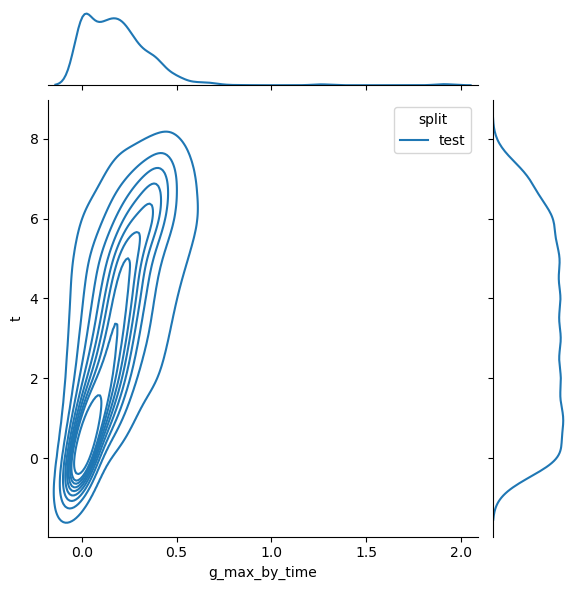

<Figure size 640x480 with 0 Axes>

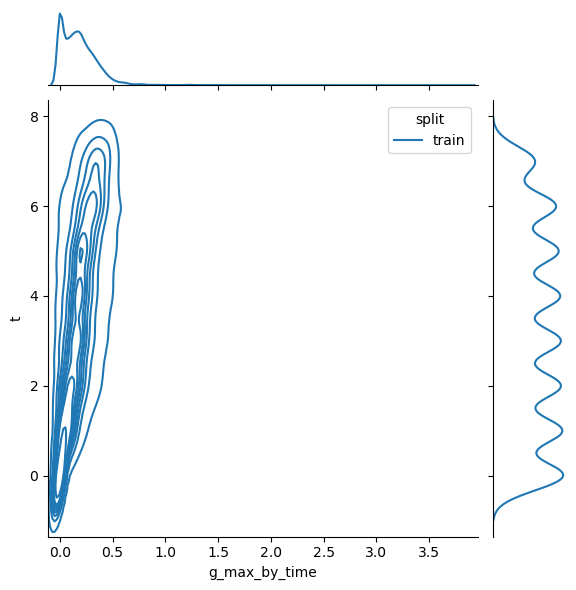

<Figure size 640x480 with 0 Axes>

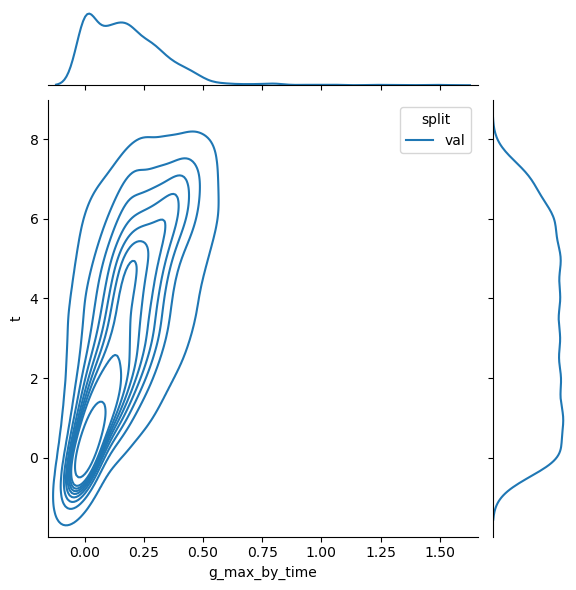

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
for split, df in df_y_train_test_val.groupby('split'):
    plt.figure()
    sns.jointplot(
        data=df,
        y='t',
        x='g_max_by_time',
        hue='split',
        kind='kde'
    )

In [14]:
df_features_train_test_val['split'].value_counts(normalize=True)

split
train    0.82586
test     0.08707
val      0.08707
Name: proportion, dtype: float64

In [15]:
df_features_train_test_val['split'].value_counts(normalize=False)

split
train    1897
test      200
val       200
Name: count, dtype: int64

In [16]:
df_features_train_test_val



,traj_id,feat__is_new_build,feat__long,feat__lat,feat__frac_properties_n_beds__1,feat__frac_properties_n_beds__2,feat__frac_properties_n_beds__3,feat__frac_properties_n_beds__4,feat__frac_properties_n_beds__>=5,feat__tenure__owned_outright,...,feat__deprived_3_dim,feat__deprived_4_dim,feat__soc_grade_AB,feat__soc_grade_C1,feat__soc_grade_C2,feat__soc_grade_DE,feat__prop_type_Detached,feat__prop_type_SemiD,feat__prop_type_Terraced,split
0,E07000223DetachedExisting,False,-0.32433,50.84573,0.005065,0.056837,0.370287,0.372538,0.195273,0.578788,...,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,True,False,False,test
1,E07000223FlatExisting,False,-0.32433,50.84573,0.075017,0.712319,0.186511,0.019959,0.006194,0.226782,...,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,False,False,False,train
2,E07000223SemiExisting,False,-0.32433,50.84573,0.006395,0.114341,0.628295,0.201938,0.049031,0.416104,...,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,False,True,False,train
3,E07000223TerracedExisting,False,-0.32433,50.84573,0.002780,0.150681,0.687239,0.124270,0.035029,0.295233,...,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,False,False,True,train
4,E07000026DetachedExisting,False,-3.28096,54.68523,0.001381,0.040039,0.355030,0.413412,0.190138,0.579522,...,0.052072,0.002692,0.177782,0.240213,0.273077,0.308929,True,False,False,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2292,E06000014FlatNew,True,-1.07375,53.96582,0.242044,0.618129,0.118129,0.015911,0.005786,0.118529,...,0.030209,0.002525,0.271720,0.325356,0.185182,0.217742,False,False,False,train
2293,E06000014SemiExisting,False,-1.07375,53.96582,0.003880,0.129178,0.563087,0.231881,0.071974,0.390448,...,0.030209,0.002525,0.271720,0.325356,0.185182,0.217742,False,True,False,train
2294,E06000014SemiNew,True,-1.07375,53.96582,0.003880,0.129178,0.563087,0.231881,0.071974,0.390448,...,0.030209,0.002525,0.271720,0.325356,0.185182,0.217742,False,True,False,train
2295,E06000014TerracedExisting,False,-1.07375,53.96582,0.006363,0.294974,0.452977,0.181838,0.063848,0.236282,...,0.030209,0.002525,0.271720,0.325356,0.185182,0.217742,False,False,True,train


/tmp/ipykernel_20903/2943217258.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(3,4, figsize=(2*4, 2*3), sharex=True, sharey=True)


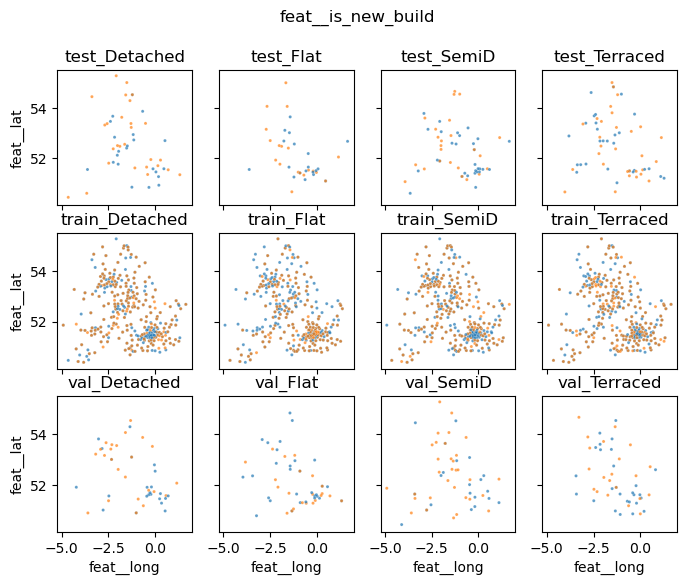

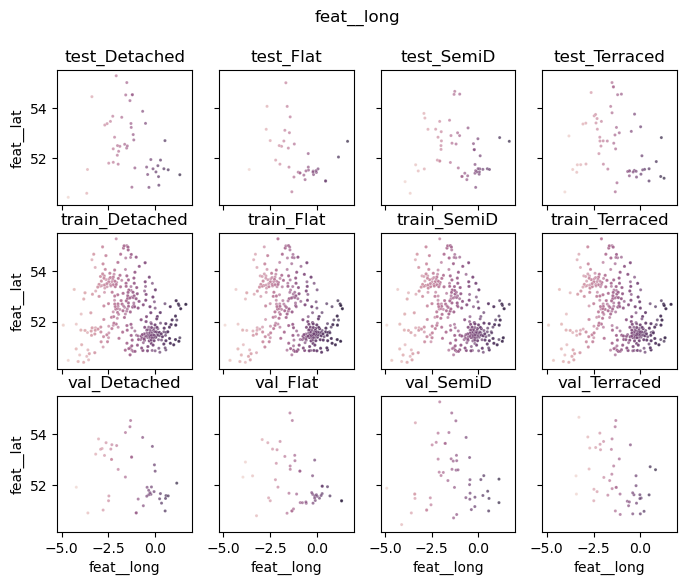

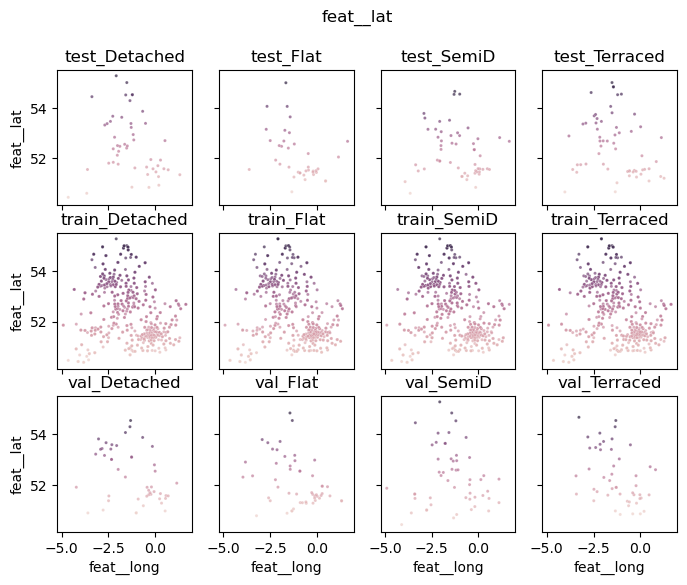

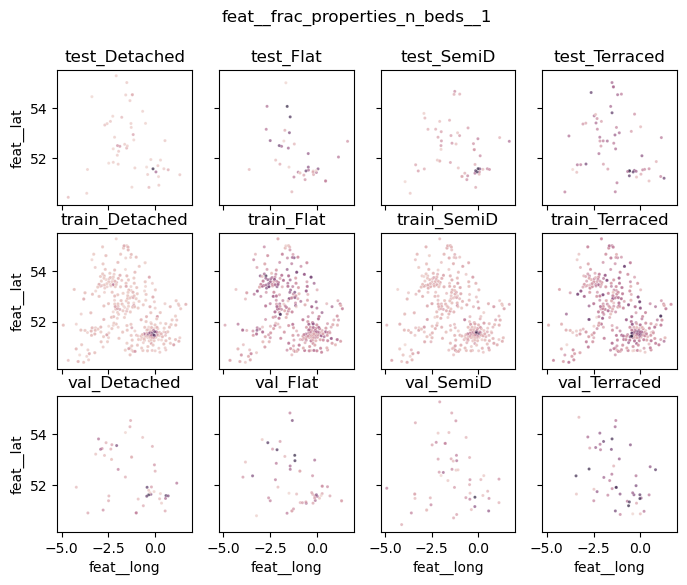

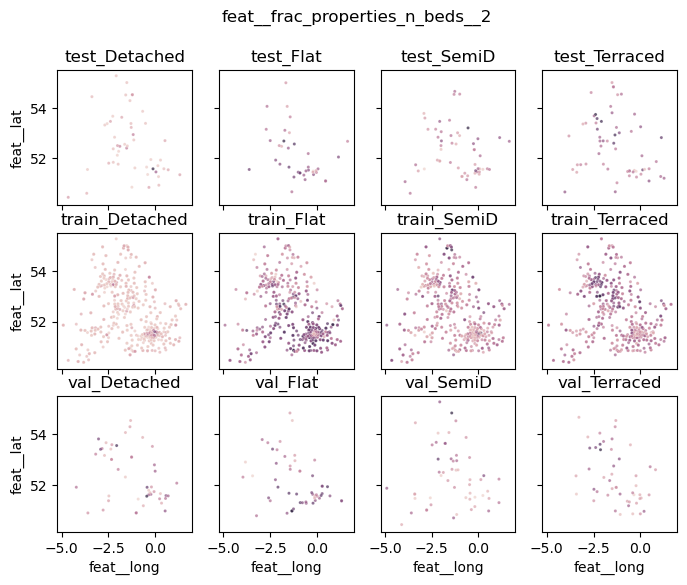

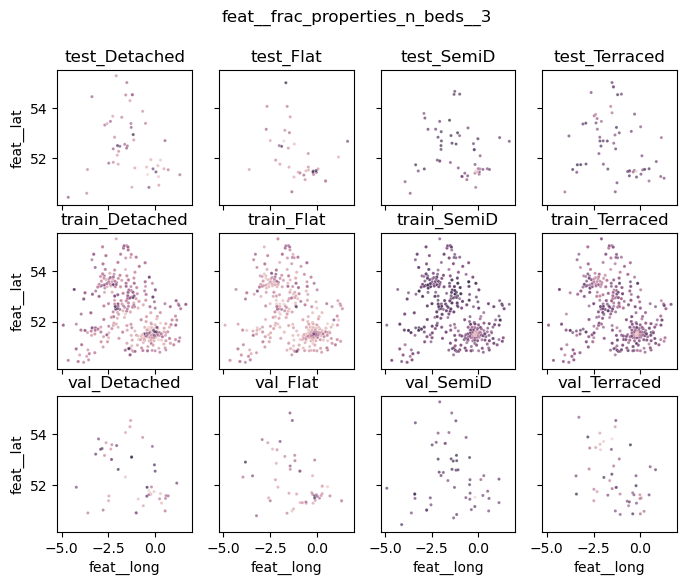

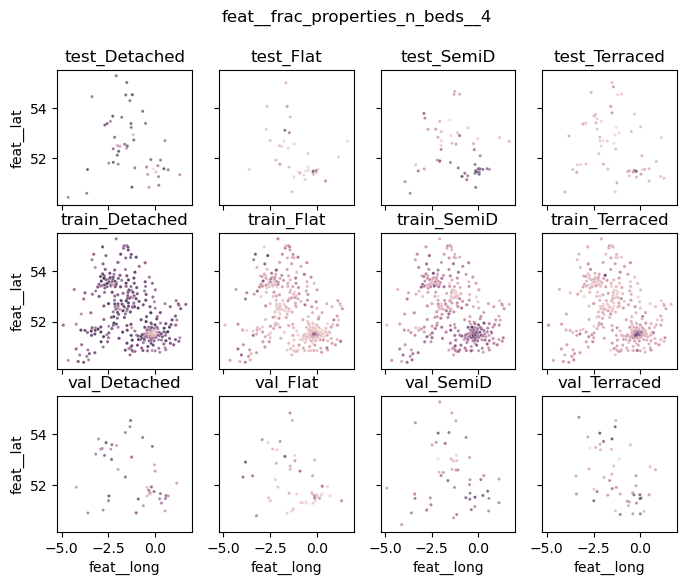

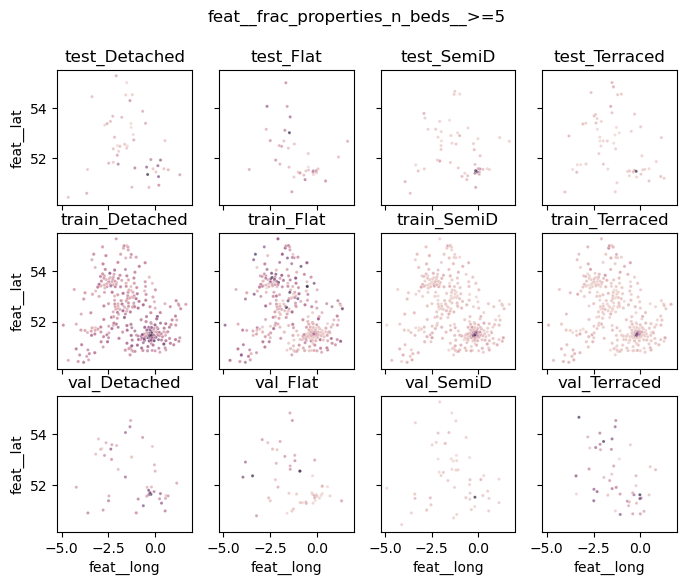

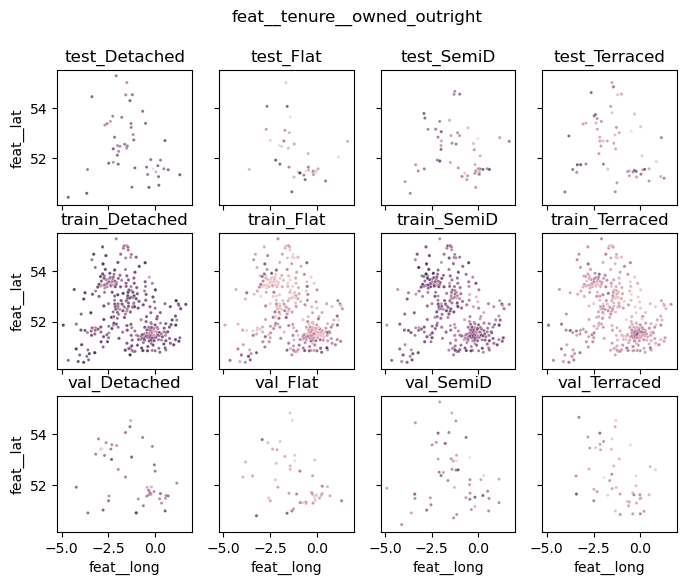

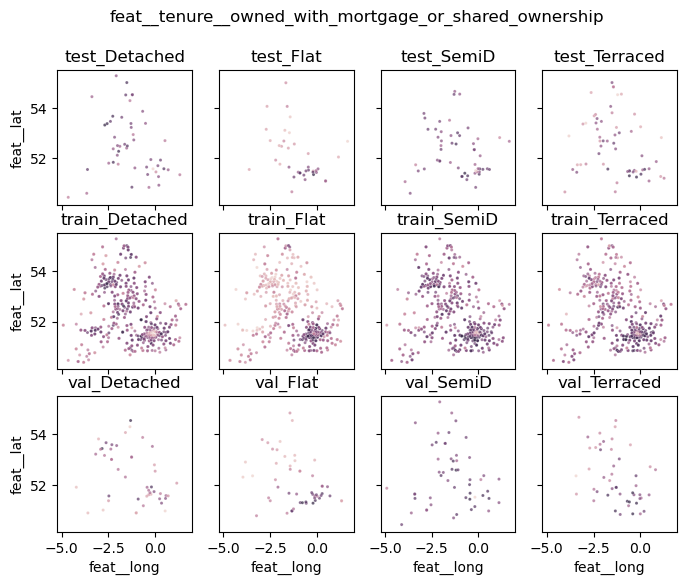

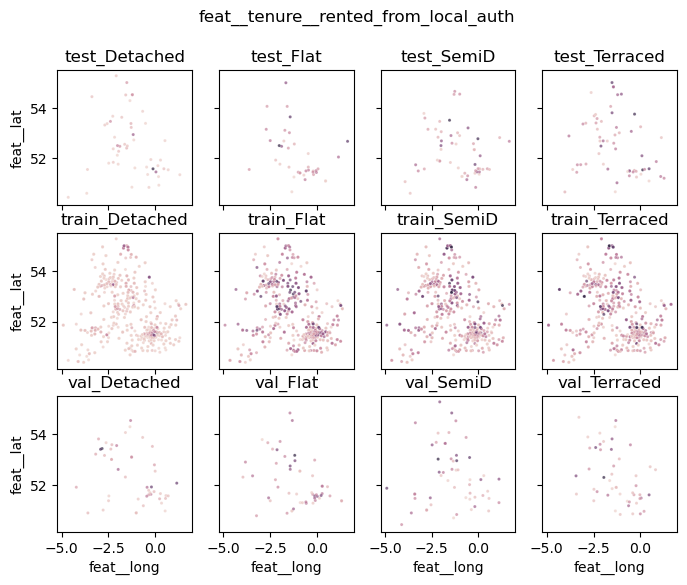

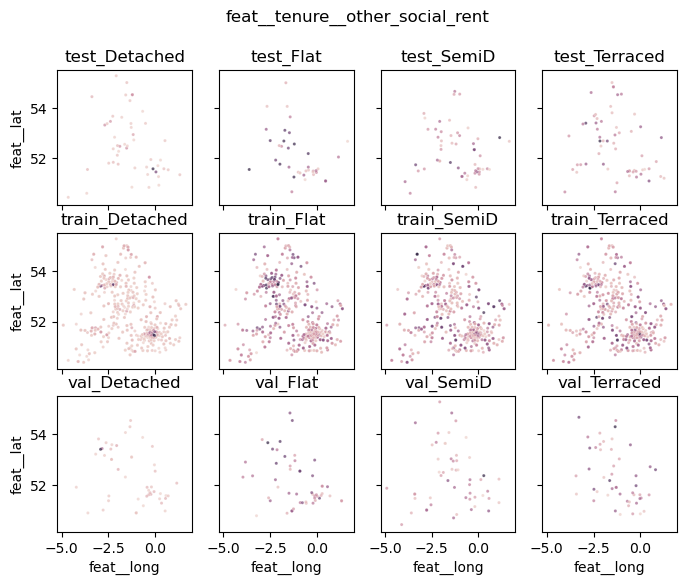

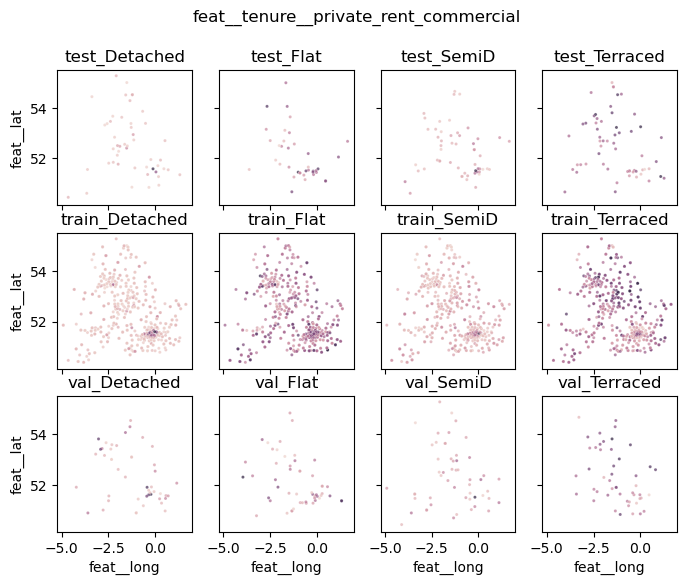

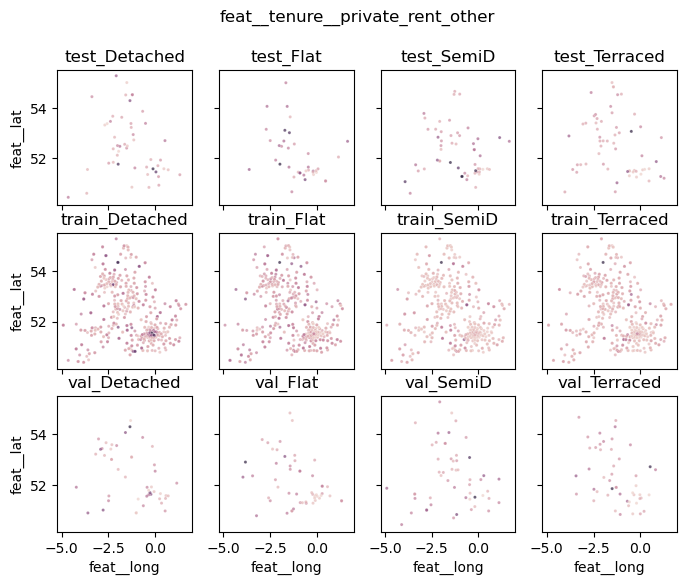

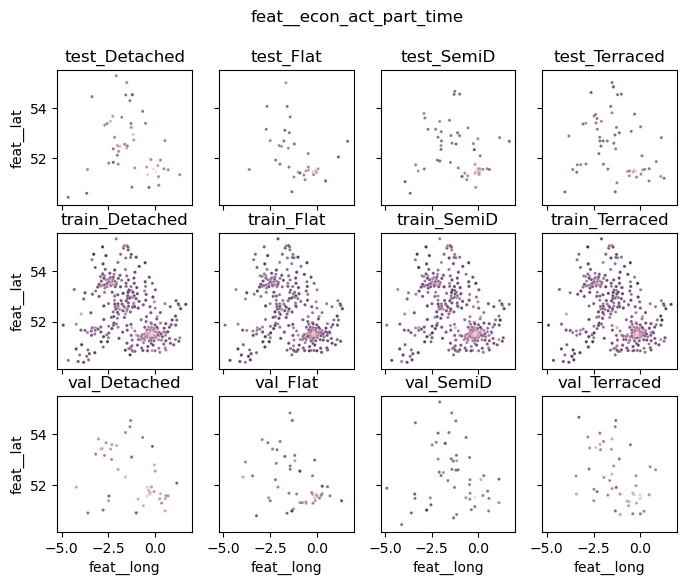

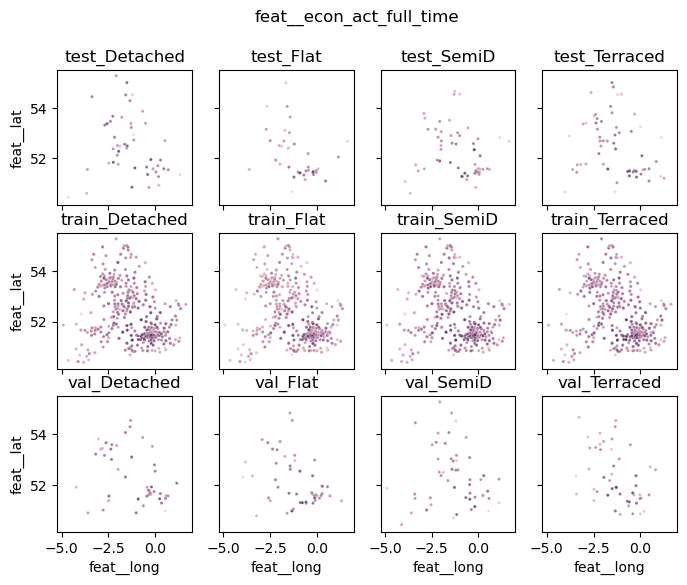

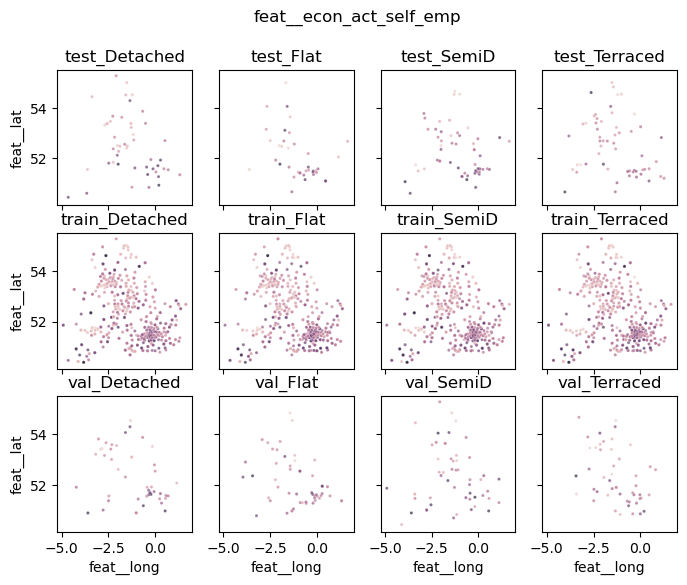

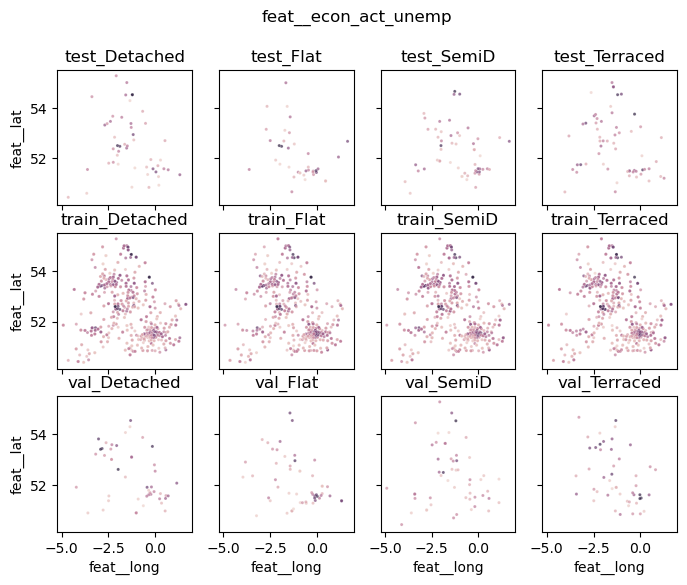

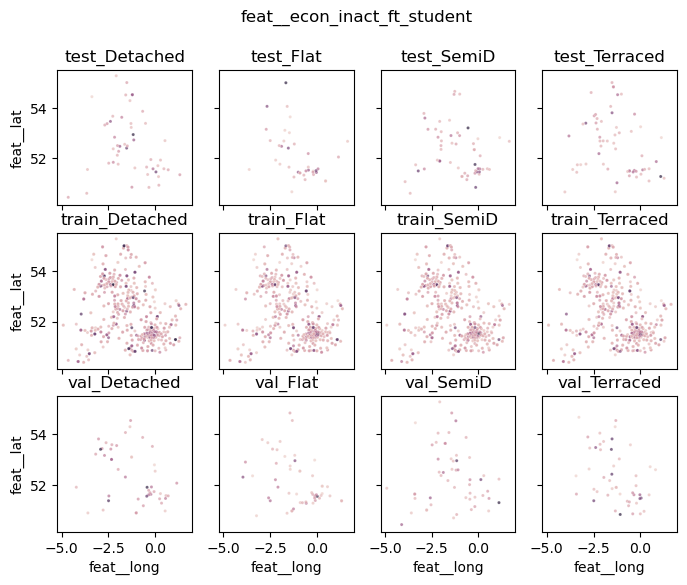

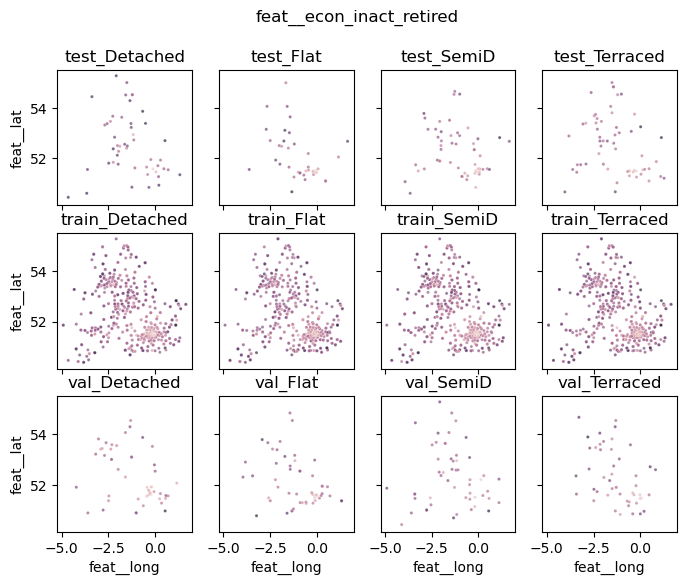

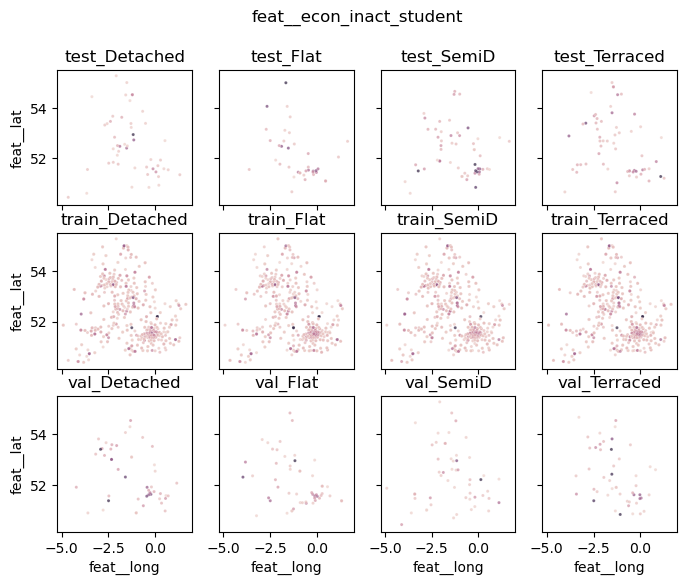

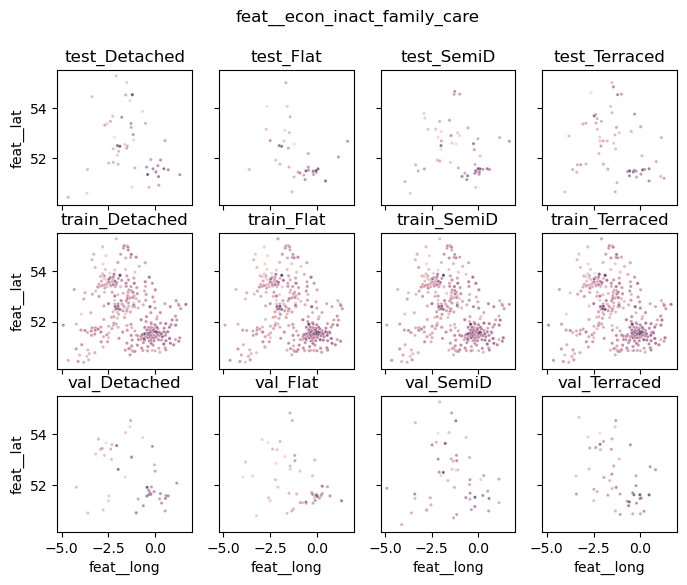

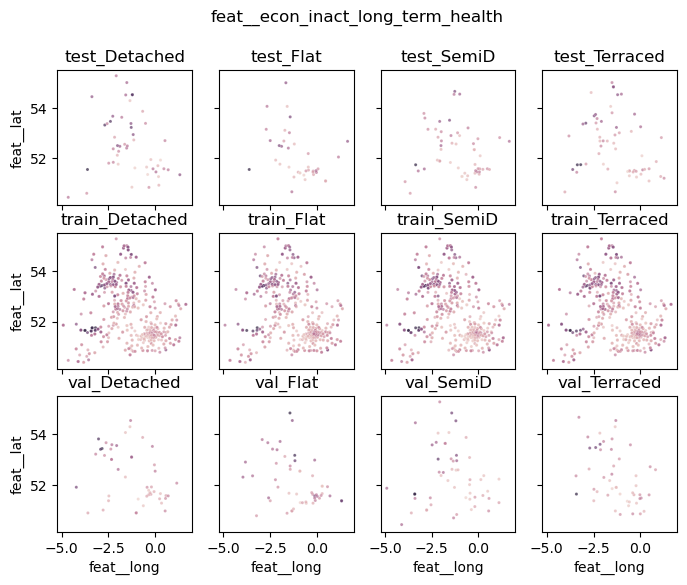

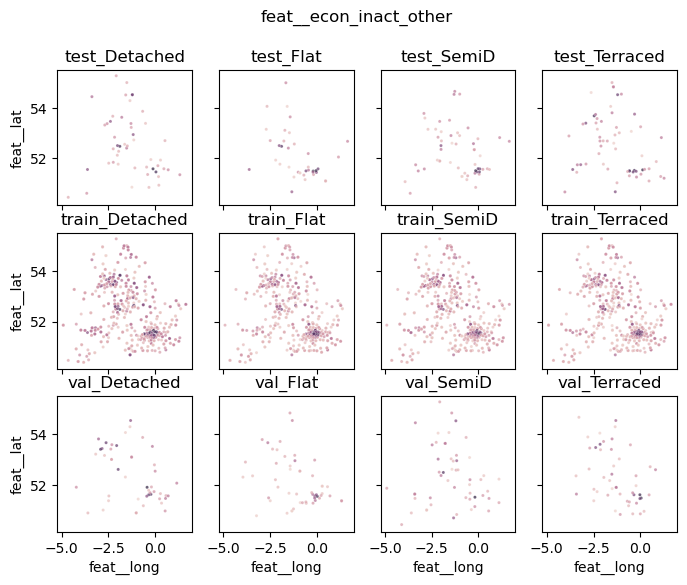

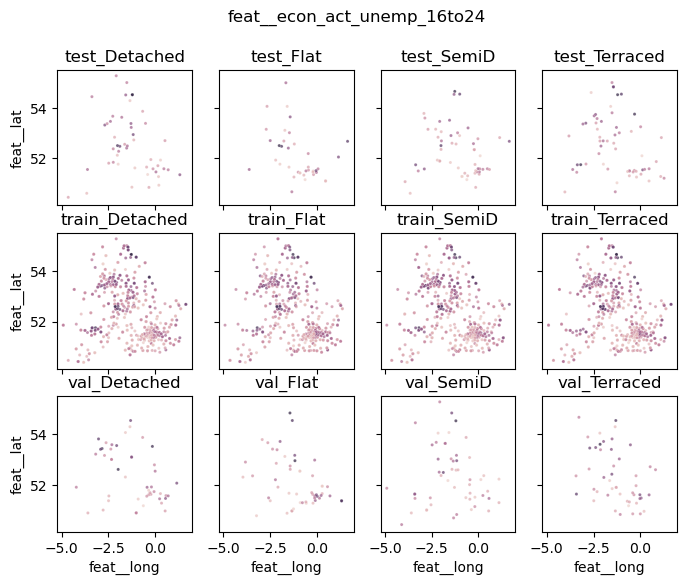

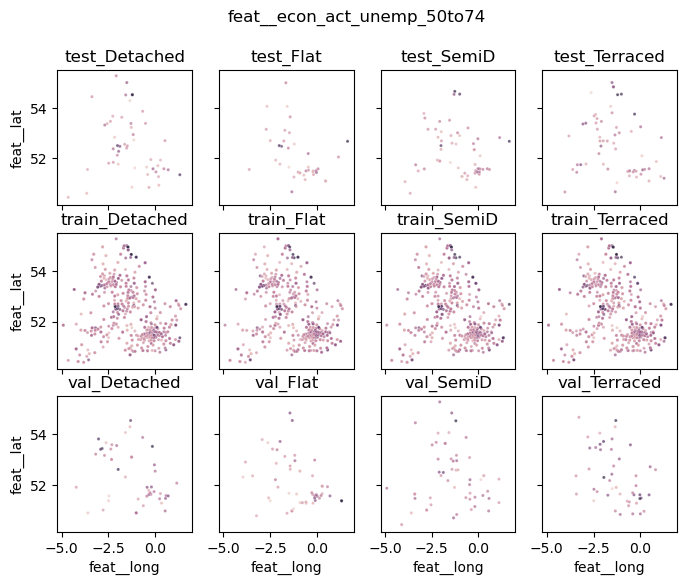

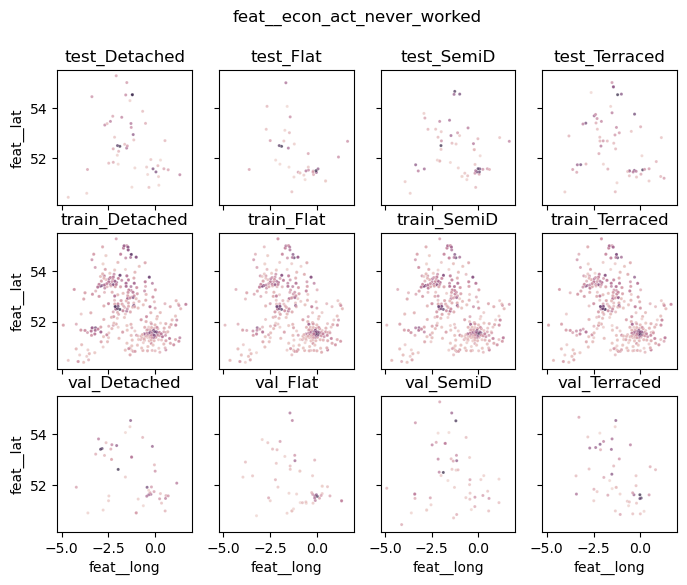

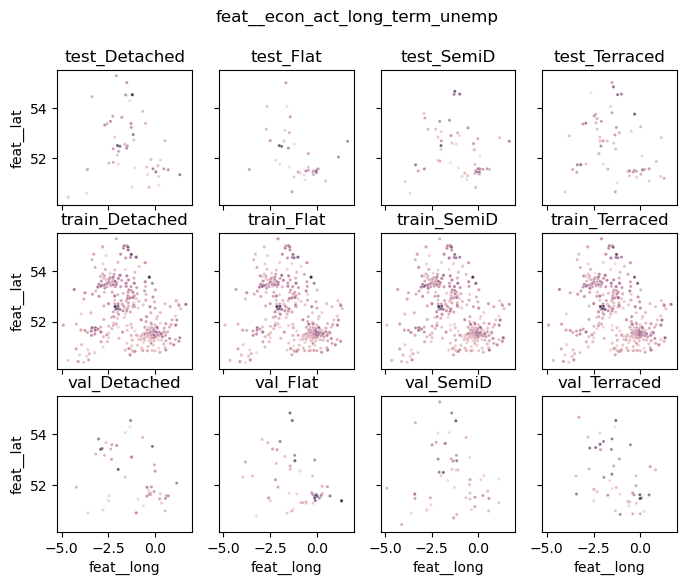

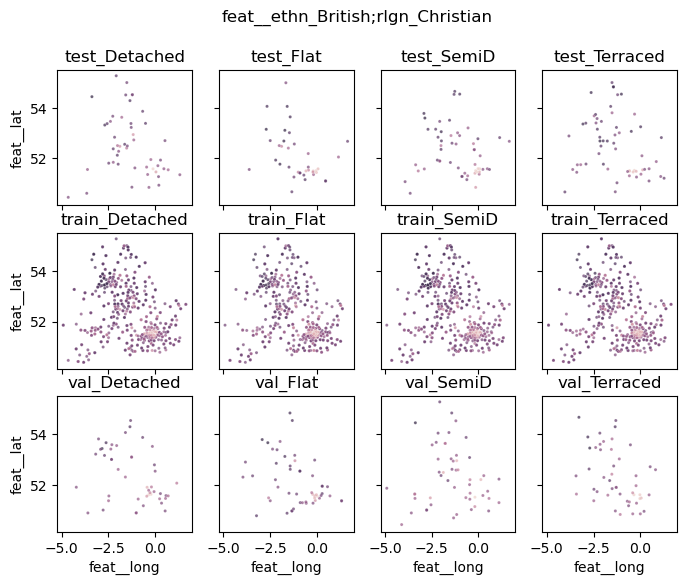

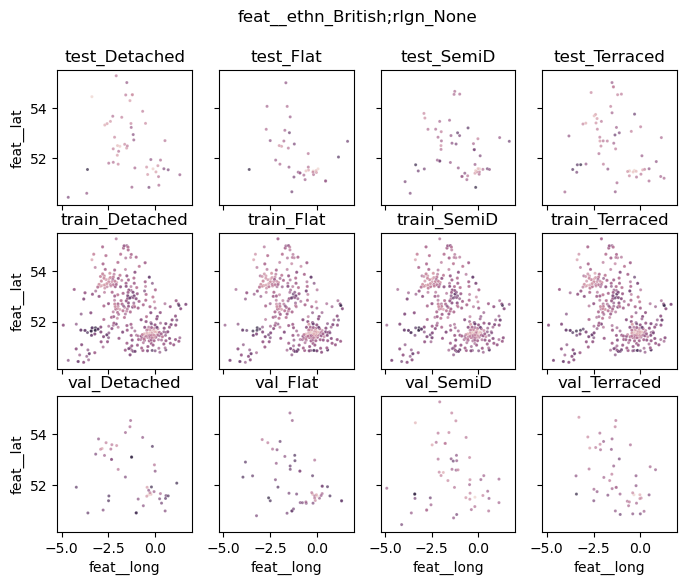

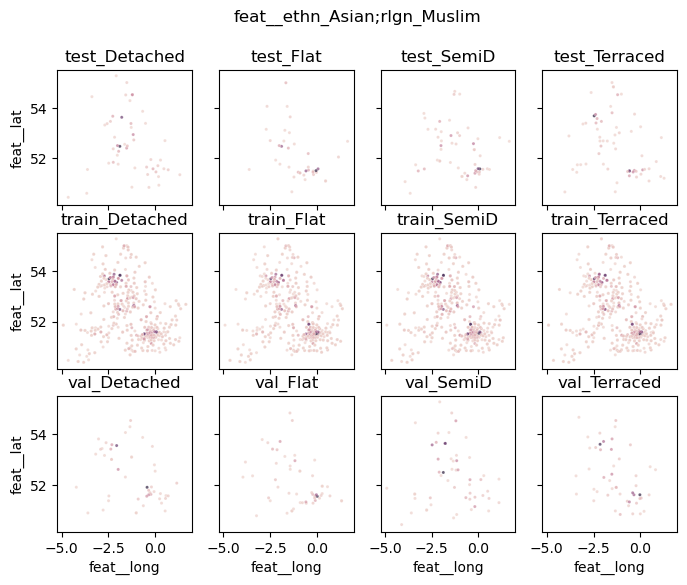

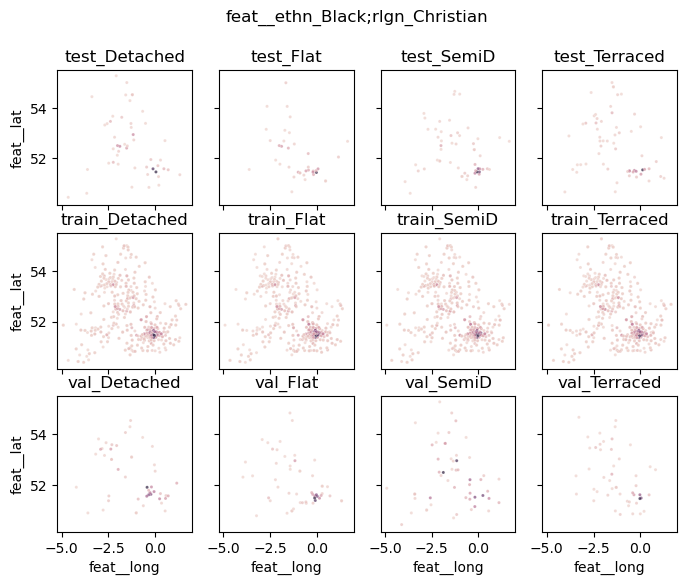

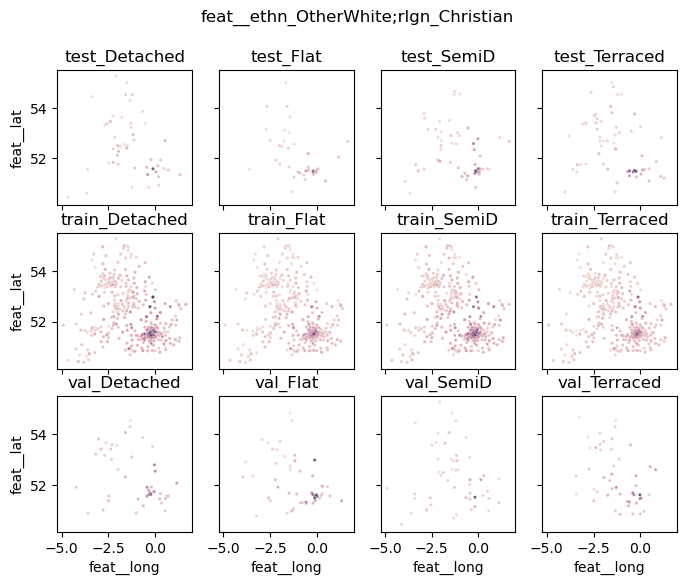

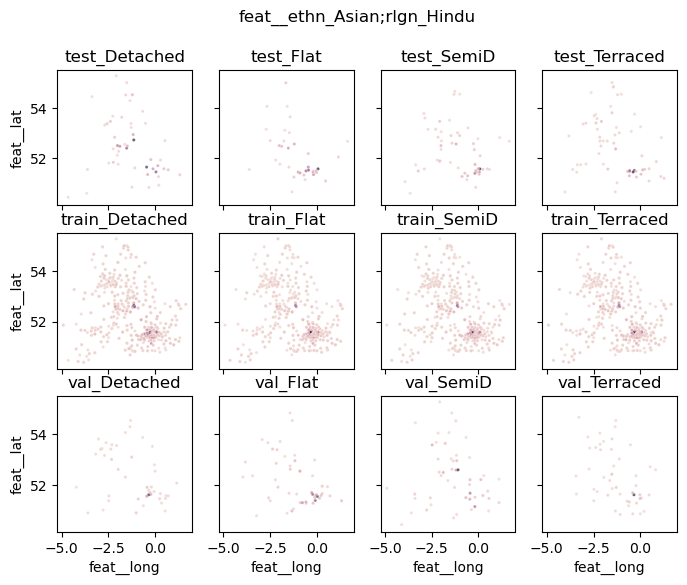

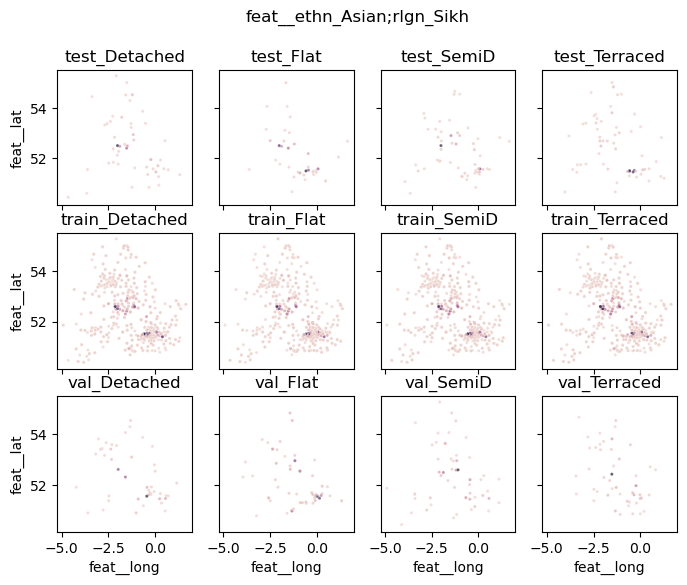

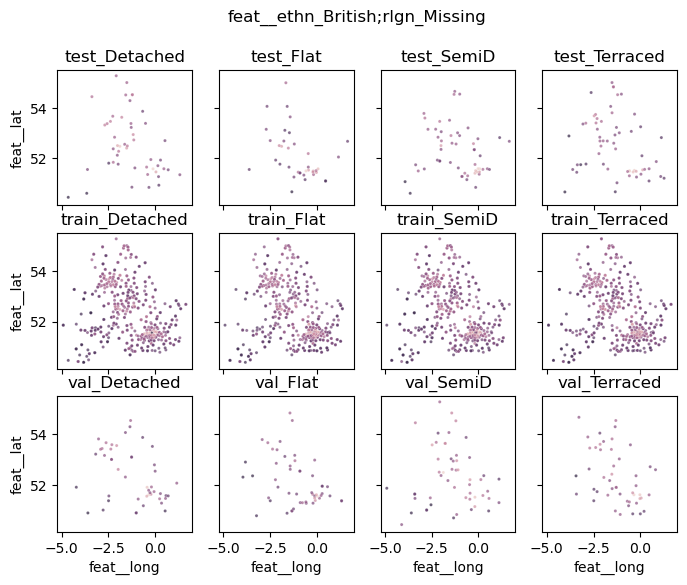

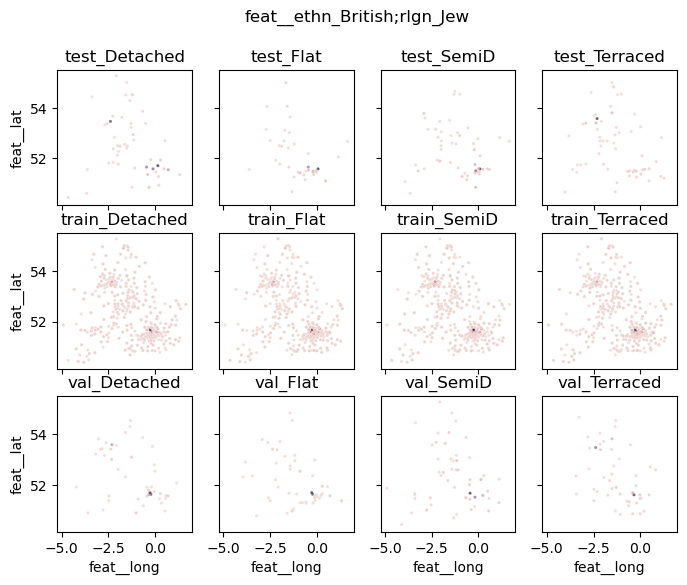

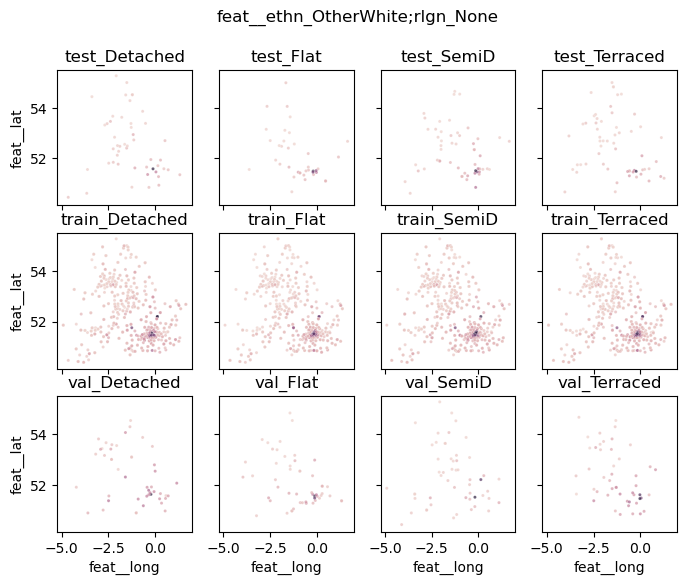

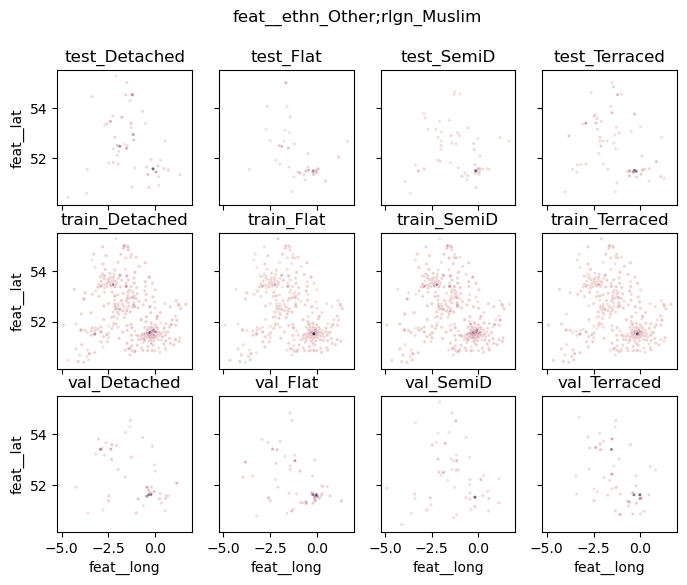

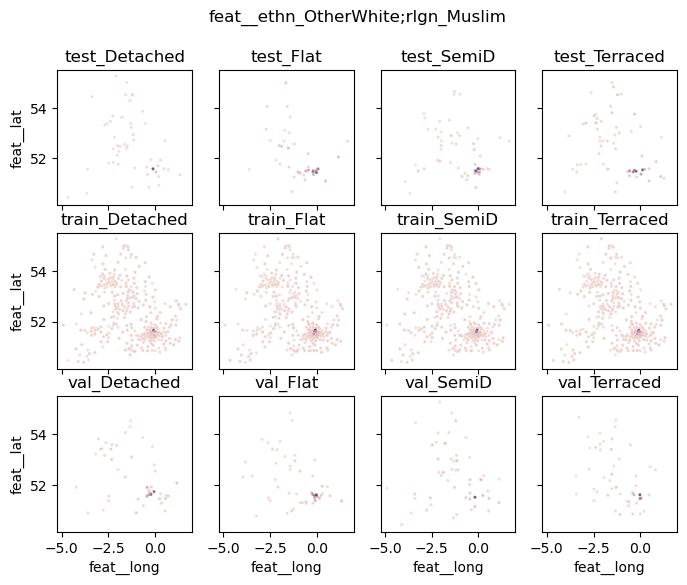

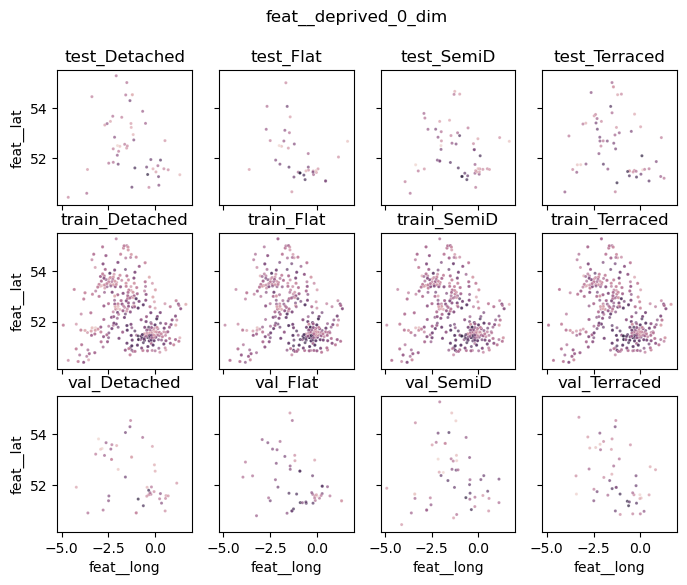

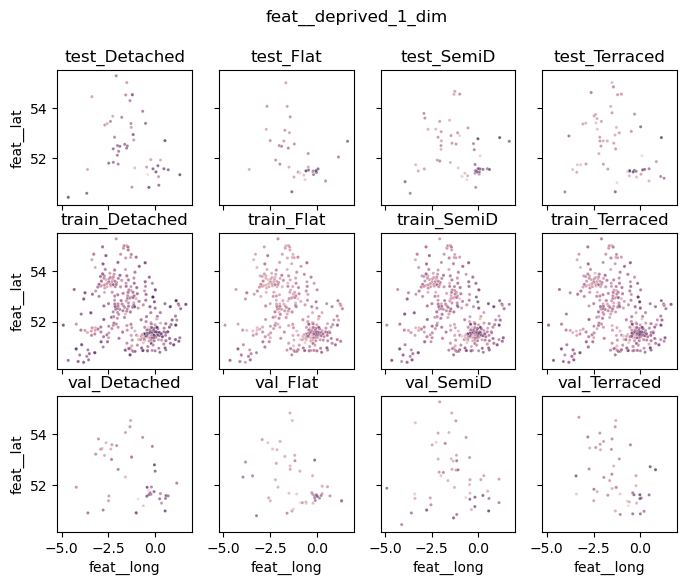

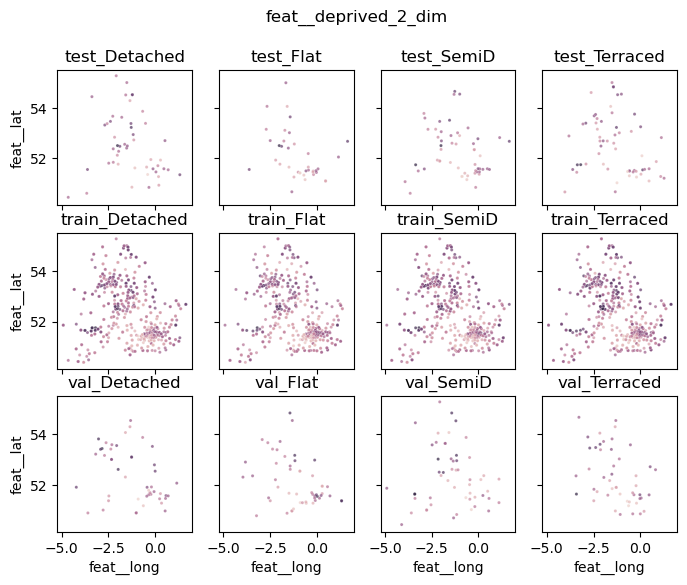

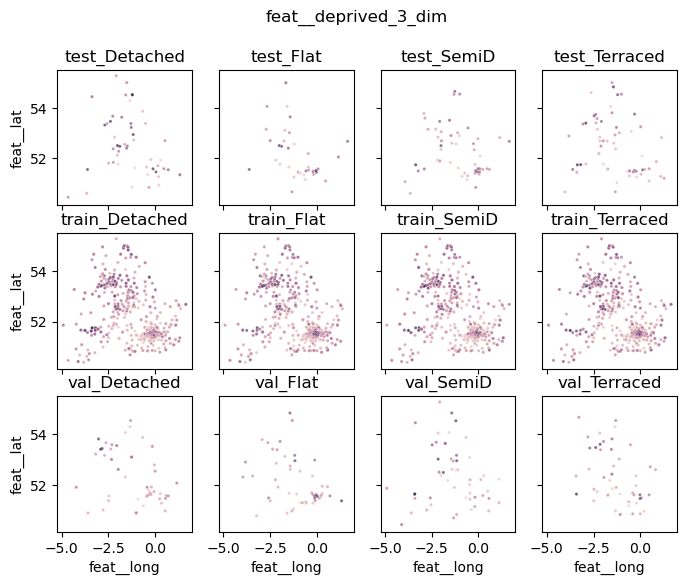

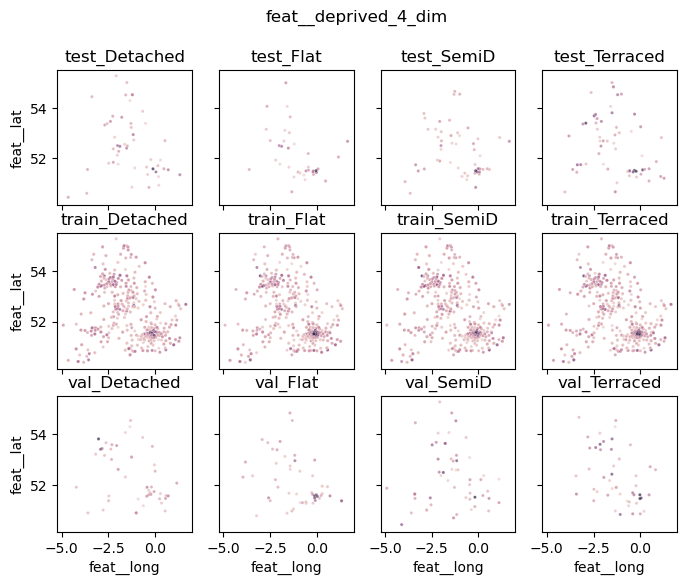

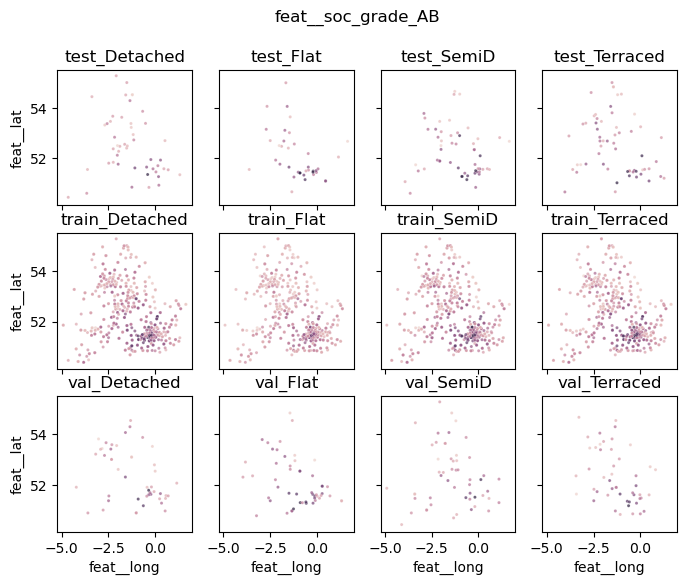

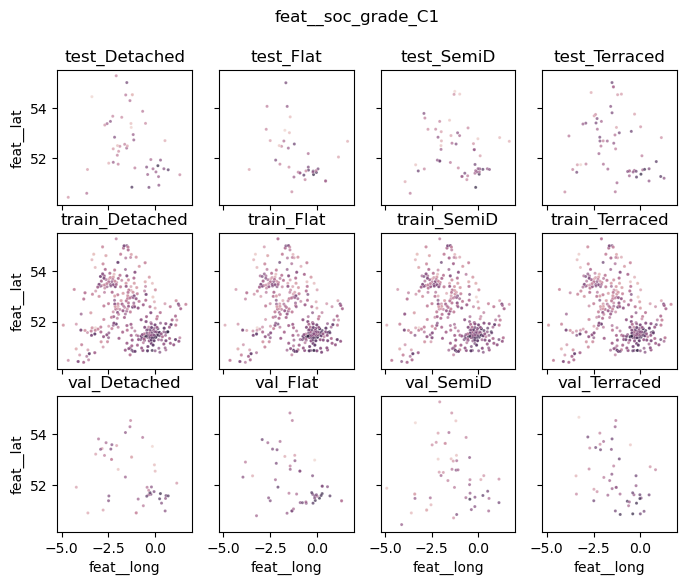

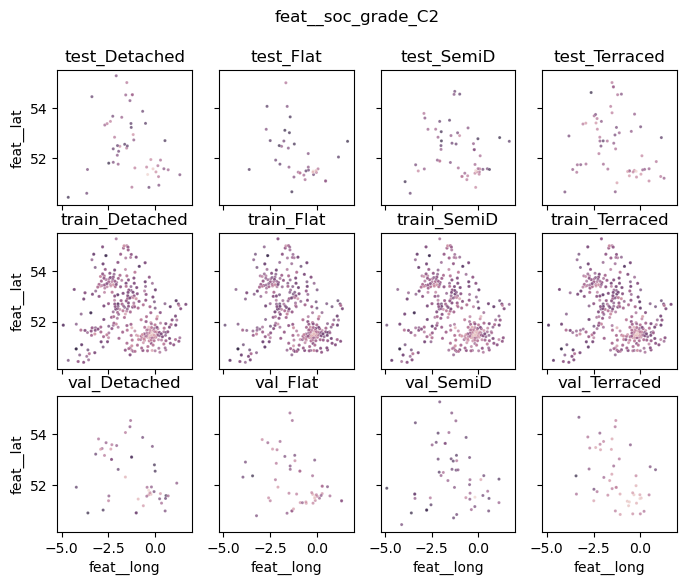

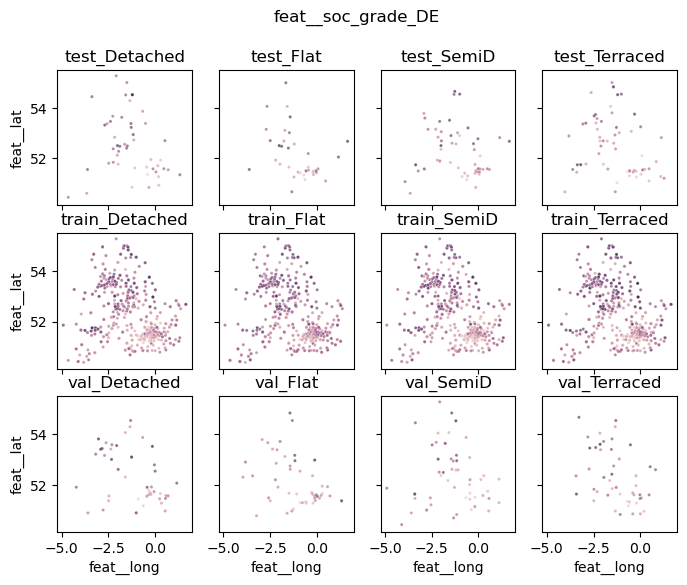

In [17]:
df_plot = df_features_train_test_val.copy()
cols_prop_type = df_plot.columns[df_plot.columns.str.startswith('feat__prop_type')]
prop_type_str = df_plot[cols_prop_type].apply(lambda x: cols_prop_type[x].str.replace('feat__prop_type_',''), axis=1)
prop_type_str = [i[0] if len(i) else 'Flat' for i in prop_type_str]
df_plot['prop_type_str'] = prop_type_str

for col in [i for i in cols_feats if i not in cols_prop_type]:

    fig, axes = plt.subplots(3,4, figsize=(2*4, 2*3), sharex=True, sharey=True)
    for (grp, df), ax in zip(df_plot.groupby(['split','prop_type_str']), axes.flatten()):
        split, prop_type = grp
        sns.scatterplot(
            data=df,
            y='feat__lat',
            x='feat__long',
            hue=col,
            ax=ax,
            s=5,
            alpha=0.7,
        )
        ax.set(title=f'{split}_{prop_type}')
        ax.legend().remove()
    fig.suptitle(col)

/tmp/ipykernel_20903/691614602.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,1, figsize=(4, 3))


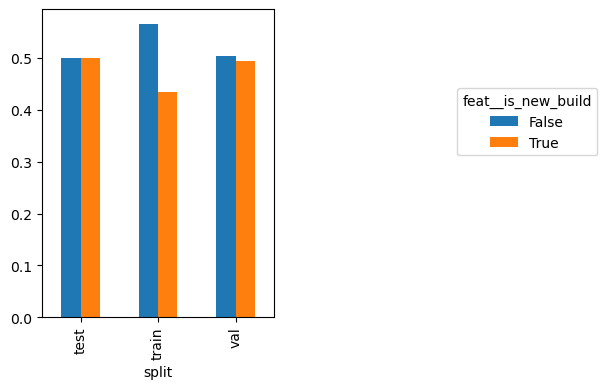

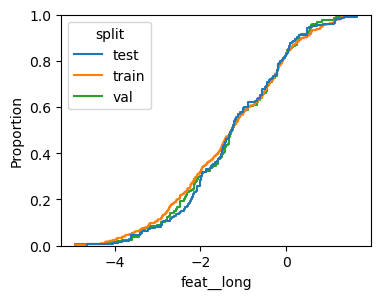

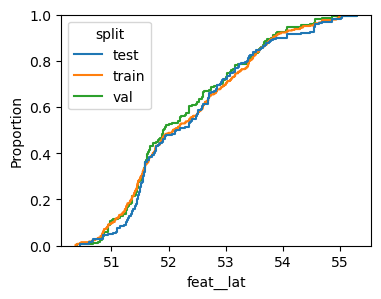

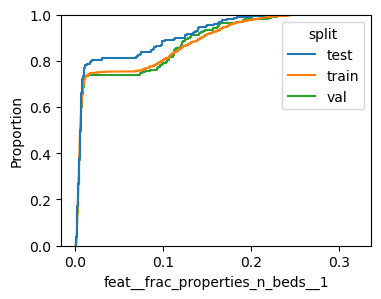

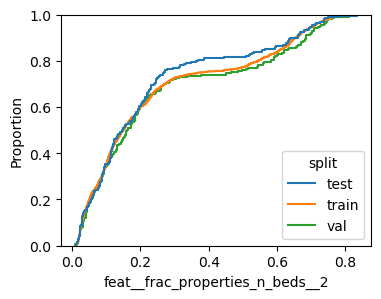

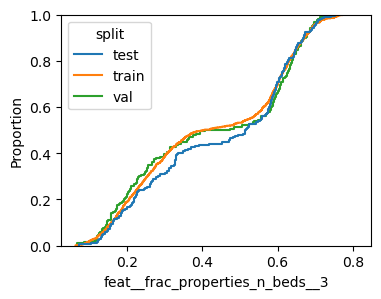

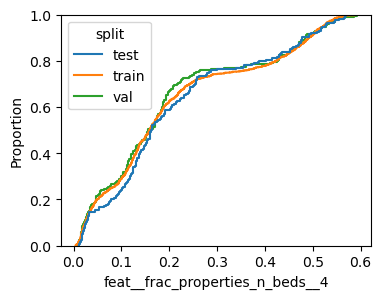

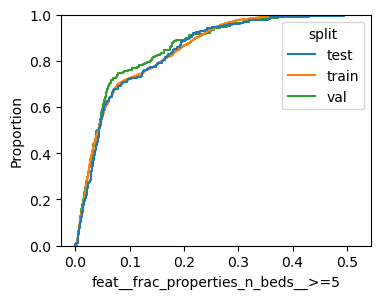

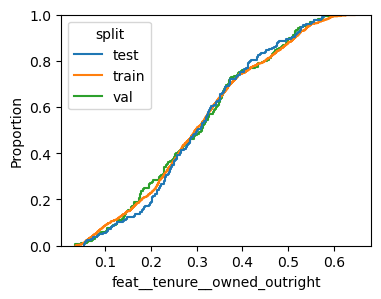

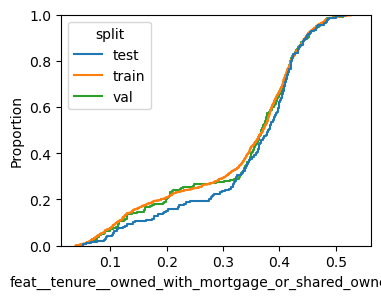

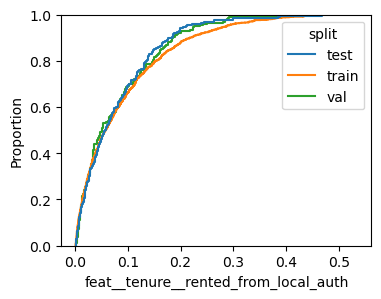

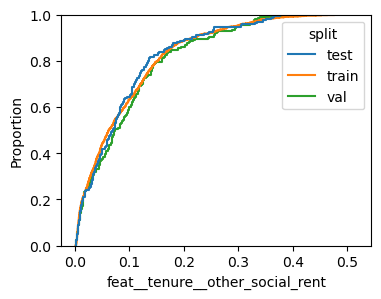

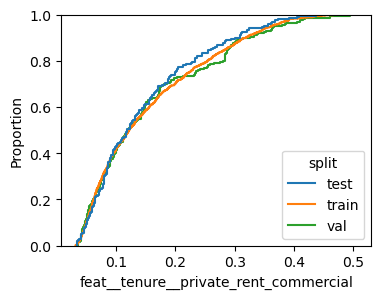

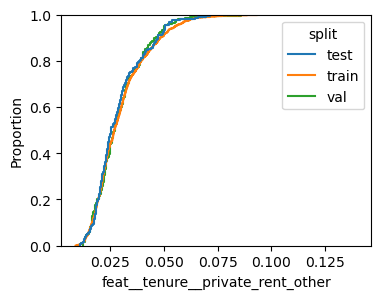

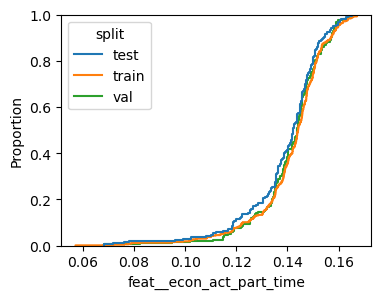

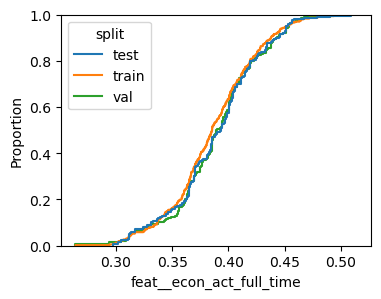

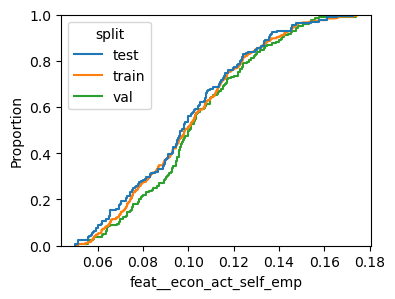

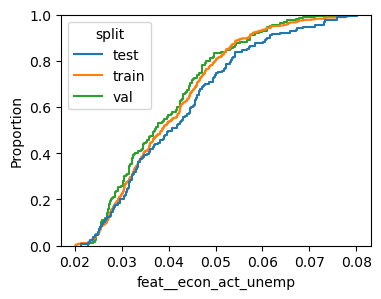

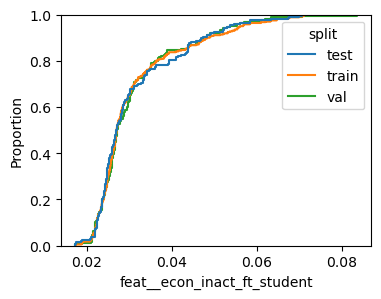

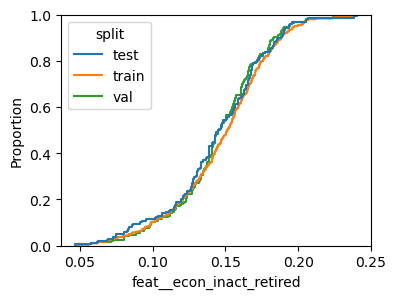

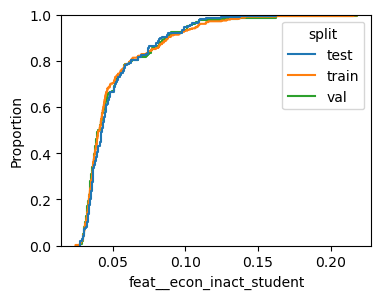

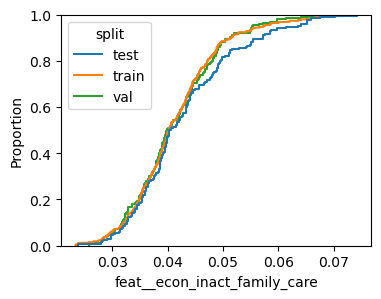

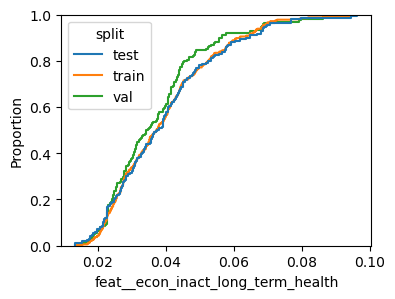

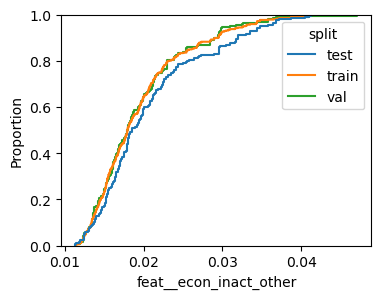

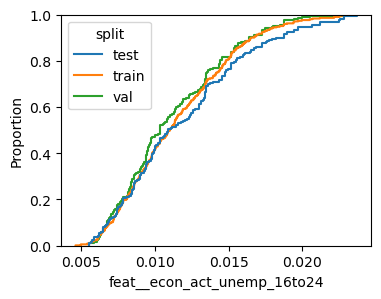

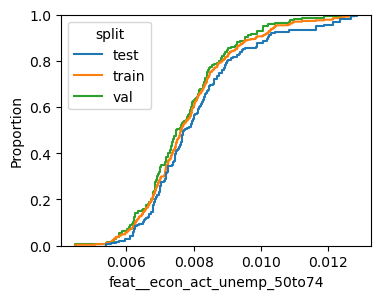

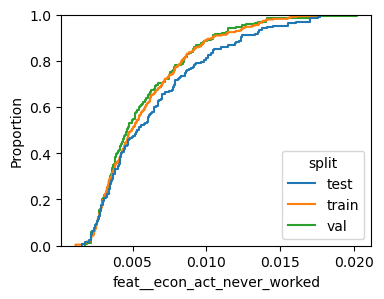

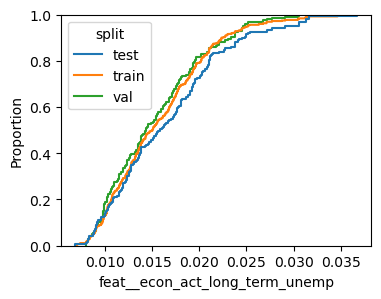

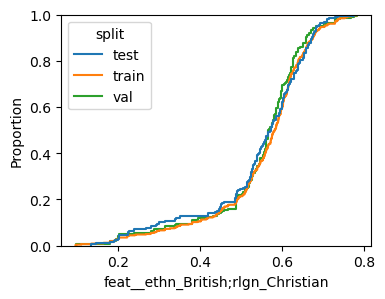

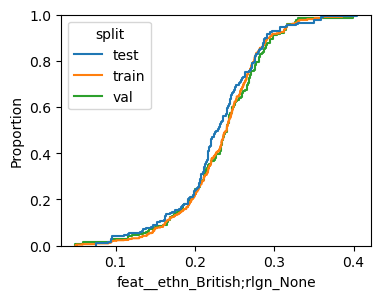

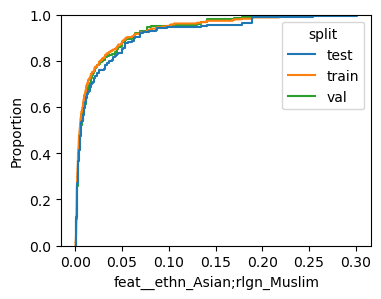

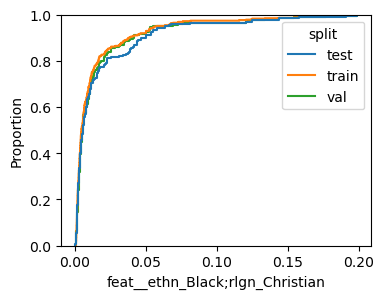

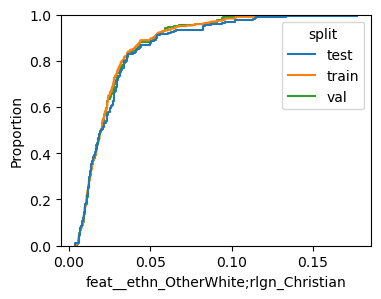

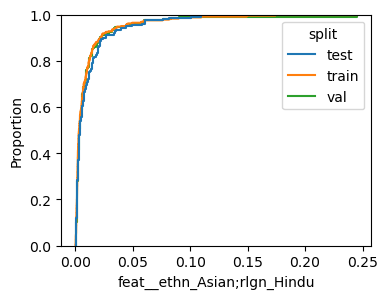

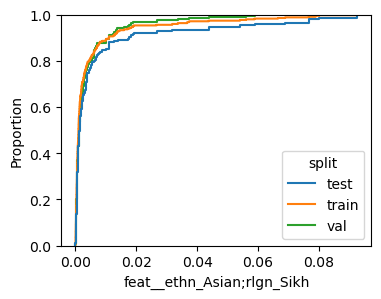

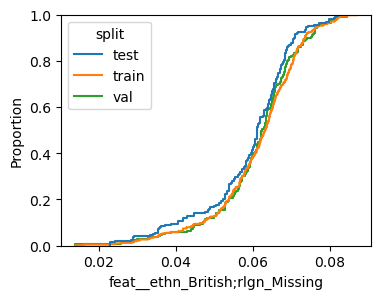

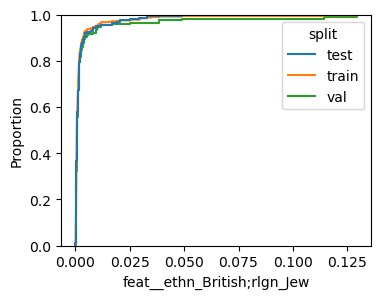

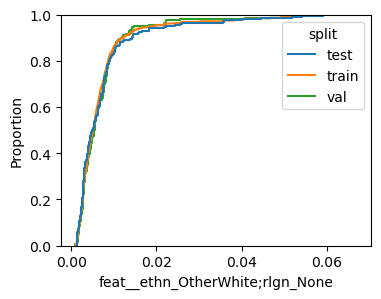

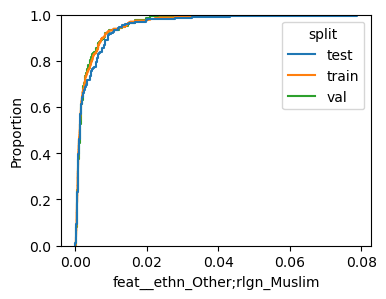

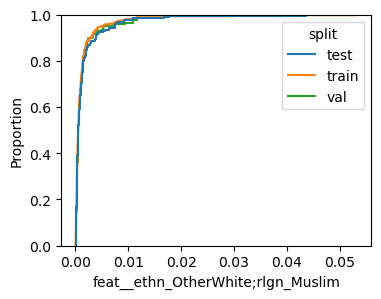

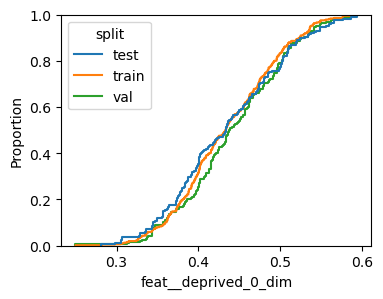

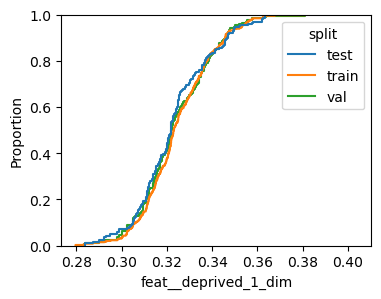

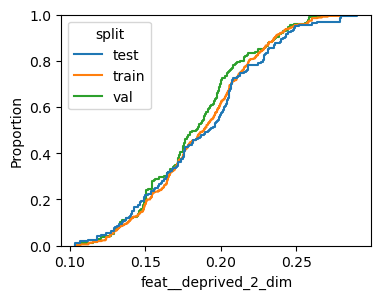

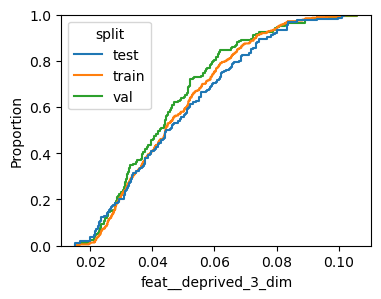

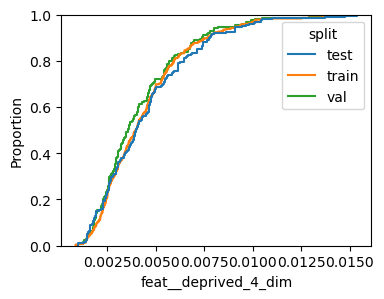

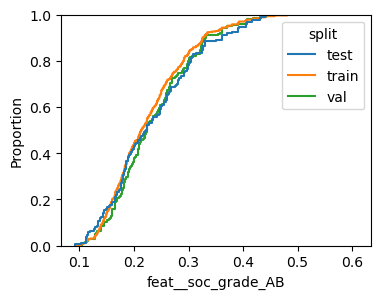

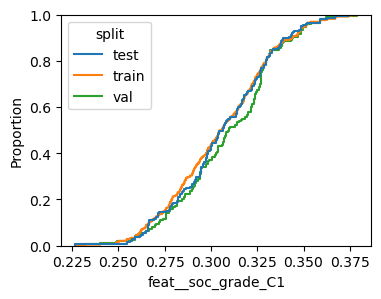

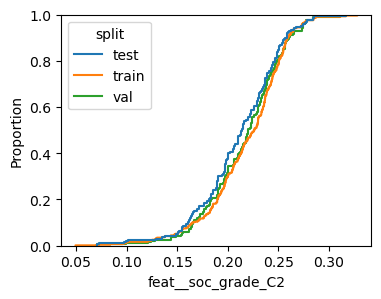

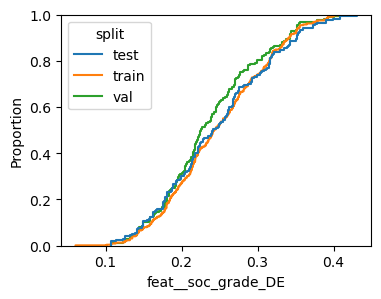

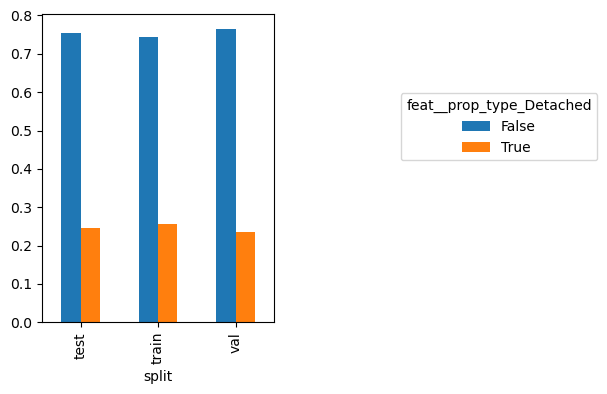

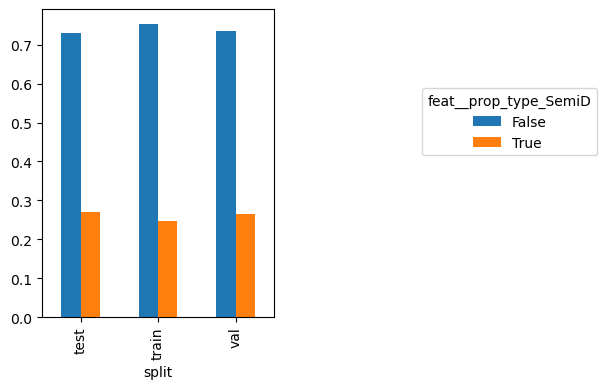

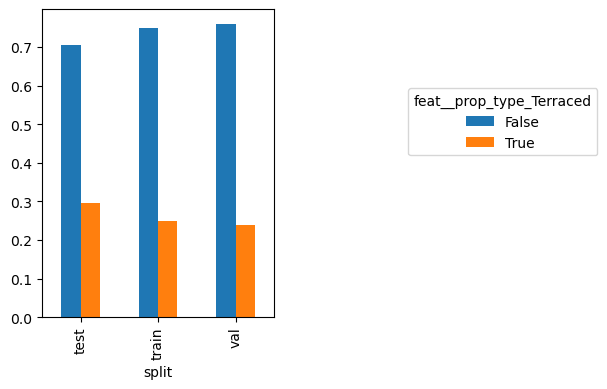

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in cols_feats:
    if df_features[col].nunique() > 5:
        fig, ax = plt.subplots(1,1, figsize=(4, 3))
        sns.ecdfplot(
            data=df_features_train_test_val,
            x=col,
            hue='split',
            ax=ax
        )
    else:
        df = pd.crosstab(
            df_features_train_test_val[col],
            df_features_train_test_val['split'],
        )
        df = (df/df.sum()).T
        fig, ax = plt.subplots(1,1, figsize=(3,4))
        df.plot(kind='bar', ax=ax, legend=False)

        fig.legend(bbox_to_anchor=(2, 0.7), title=col)

In [19]:
df_event_time

,traj_id,t,g_max_by_time
6575,E06000001DetachedExisting,0.0,0.000000
6576,E06000001DetachedExisting,1.0,0.000580
6577,E06000001DetachedExisting,2.0,0.000580
6578,E06000001DetachedExisting,3.0,0.008855
6579,E06000001DetachedExisting,4.0,0.035069
...,...,...,...
8670,W06000024TerracedExisting,3.0,0.117148
8671,W06000024TerracedExisting,4.0,0.174270
8672,W06000024TerracedExisting,5.0,0.238708
8673,W06000024TerracedExisting,6.0,0.351439


In [20]:
from sklearn.preprocessing import StandardScaler
for suffix, subj in [
    ('train', subj_train),
    ('tune', subj_train_tune),
    ('val', subj_val),
    ('test', subj_test)
]:
    print(f'n_traj in {suffix}:{len(subj)}')
    

    df_features_sub = df_features.loc[
        df_features[col_traj_id].isin(subj),
        :
    ].copy()

    if suffix == 'train':
        transform = StandardScaler().fit(df_features_sub[col_numer])
        cols_cat_max = df_features_sub[col_cat].max()
    df_features_sub[col_numer] = transform.transform(df_features_sub[col_numer])
    df_features_sub[col_cat] = df_features_sub[col_cat].astype(float)/cols_cat_max
    df_features_sub.to_csv(os.path.join(DIR_SPLIT_OUT, f'{dataset_name_dir}__df_features_{suffix}.csv'))
    print(f'subj feat df shape: {df_features_sub.shape}')

    df_event_time_sub = df_event_time.loc[
        df_event_time[col_traj_id].isin(subj),
        :
    ]
    
    df_event_time_sub.to_csv(os.path.join(DIR_SPLIT_OUT, f'{dataset_name_dir}__df_state_history_sampled_max_{suffix}.csv'))
    print(f'subj traj df shape: {df_event_time_sub.shape}')

del df_event_time
del df_features_sub
del df_features


n_traj in train:1897
subj feat df shape: (1897, 53)
subj traj df shape: (13780, 3)
n_traj in tune:948
subj feat df shape: (948, 53)
subj traj df shape: (6910, 3)
n_traj in val:200
subj feat df shape: (200, 53)
subj traj df shape: (1431, 3)
n_traj in test:200
subj feat df shape: (200, 53)
subj traj df shape: (1420, 3)


In [21]:
len(col_numer) + len(col_cat)

52